# Setup

In [2]:
from manim import *
import numpy as np
config.media_width = "75%"
config.verbosity = "WARNING"

# colors
gradient_colors = ["#009245", "#FCEE21"]

col1 = "#008e9f"
col2 = "#007ac3"
col3 = "#d6fadc"
col4 = "#8aa2ff"
col5 = "#00968e"
col6 = "#fcee21"
col7 = "#009245"
col8 = "#bd5942"

Manim Community v0.18.1

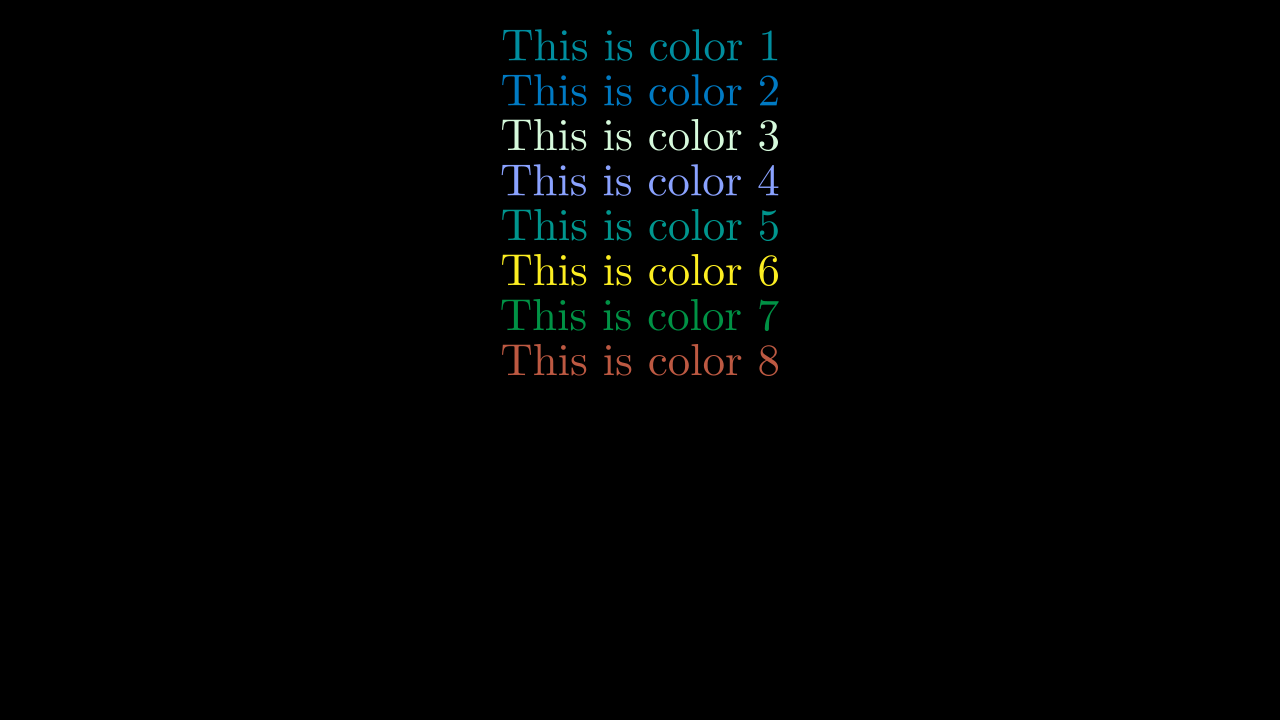

In [38]:
%%manim -qm Colors

class Colors(Scene):
    def construct(self):
        colors = [col1, col2, col3, col4, col5, col6, col7, col8]
        for i in range(len(colors)):
            tex = Tex(f"This is color {i+1}")
            tex.set_color(colors[i])
            tex.move_to(UP*(3.5 - 0.5*i))
            self.add(tex)

Manim Community v0.18.1

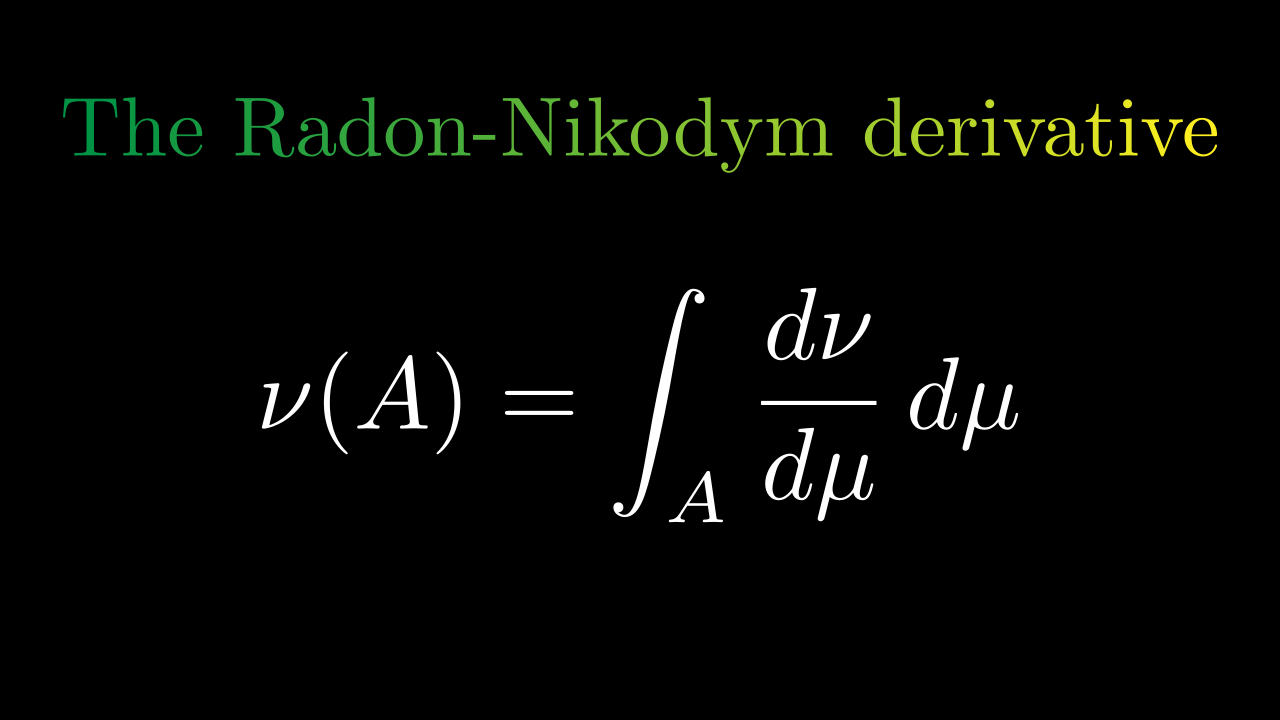

In [5]:
%%manim -qm Thumbnail

class Thumbnail(Scene):
    def construct(self):
        title = Tex(r"The Radon-Nikodym derivative", font_size=90)
        title.move_to(UP*2.5)
        title.set_color_by_gradient(*gradient_colors)
        self.add(title)

        radon = MathTex(r"\nu(A) = \int_A  \frac{d\nu}{d\mu} \, d\mu", font_size = 110)
        radon.move_to(DOWN*0.5)

        self.add(radon)

# Title

In [24]:
%%manim -qm S1

class S1(ThreeDScene):
    def construct(self):
        #self.set_camera_orientation(phi=75*DEGREES, theta=-45*DEGREES)

        axes = ThreeDAxes()
        cube = Cube(side_length=3, fill_opacity=0.5, fill_color=col)
        cube.set_z_index(1)
        cube.rotate(angle= PI/8, axis=UP, about_point=ORIGIN)
        self.add(cube)
        self.play(
        Rotating(
            cube, 
            radians=PI/2, 
            axis=UP,
            about_point=ORIGIN
        ), run_time=2)
        self.play(cube.animate.shift(0), run_time=0.3)

        cube2 = Cube(side_length=1, fill_opacity=0.95, fill_color=RED)
        cube2.set_z_index(0)
        cube2.rotate(angle= PI/8, axis=UP, about_point=ORIGIN)

        self.add(cube2)
        self.play(cube2.animate.shift(0), run_time=0.5)

        tex = MathTex(r"\text{Mass } m(A) = ", "5")
        tex[0][6].set_color(RED)
        tex.move_to(UP*2.7)
        tex2 = MathTex(r"\text{Mass} m(A) = ", "7")
        tex2.move_to(UP*2.7)
        tex3 = MathTex(r"\text{Mass} m(A) = ", "4")
        tex3.move_to(UP*2.7)
        tex4 = MathTex(r"\text{Mass } m: \mathcal{F} \to [0,\infty]")
        tex4.move_to(UP*2.7)
        
        
        self.play(Write(tex), cube2.animate.shift(0))
        self.play(cube2.animate.shift(0), run_time=1)

        self.play(cube2.animate.shift(DOWN*0.4 + LEFT*0.3), Transform(tex[1], tex2[1]))

        self.play(cube2.animate.shift(0), run_time=1)

        self.play(cube2.animate.shift(UP*1 + RIGHT*1.2), Transform(tex[1], tex3[1]))

        self.play(cube2.animate.shift(0), run_time=1)

        self.play(Transform(tex, tex4), cube2.animate.shift(0))

        cubegroup = VGroup(cube, cube2)
        self.play(cubegroup.animate.shift(LEFT*3.5))

        den = MathTex(r"\text{Density }", r"\rho")
        den.set_color_by_tex("rho", BLUE)
        den.move_to(UP*1.7 + RIGHT*3.5)
        approx = MathTex(r"\text{For small }", r"A", r"\text{ with } a\in ", r" A", r",\\ m(", r"A", r") \approx", r"\rho(a)", r"\cdot \text{Vol}(", r"A", r")")
        approx.set_color_by_tex("A", RED)
        approx.set_color_by_tex("rho", BLUE)
        approx.move_to(UP*0.4 + RIGHT*3.5)
        inte = MathTex(r"m(", r"A", r") = \int_", r"A", r"\rho", r"\, d\text{Vol}")
        inte.set_color_by_tex("A", RED)
        inte.set_color_by_tex("rho", BLUE)
        inte.move_to(DOWN*1.7 + RIGHT*3.5)

        self.play(FadeIn(den), cube2.animate.shift(0))
        self.play(Write(approx), cube2.animate.shift(0))

        self.play(cube2.animate.shift(0), run_time=2)

        self.play(Write(inte), cube2.animate.shift(0))

        self.play(cube2.animate.shift(0), run_time=2)

        every = VGroup(cube, cube2, den, approx, inte, tex)
        self.play(FadeOut(every))
        

Manim Community v0.18.1

In [18]:
%%manim -qm S2

class S2(Scene):
    def construct(self):
        tex = Tex(r"Given ", r"measures ", r"$\nu, \mu$ ", r" on ", r"$(X, \mathcal{F})$")
        tex.set_color_by_tex("measures", col5)
        tex.move_to(UP*3)

        tex2 = Tex(r"Is there a ", r"measurable ", r"function $f: X \to [0,\infty)$ \\ such that $\nu(A) = \int_A f\,d\mu$ for every $A \in \mathcal{F}$?")
        tex2.set_color_by_tex("measurable", col5)
        tex2.move_to(UP*1.5)

        uniqq = Tex(r"Is $f$ ", r"unique", r"?")
        uniqq[1].set_color(col5)

        finite = Tex(r"Suppose $\nu$ and $\mu$ are", r" finite", r" \\so $\nu(X) < \infty$ and $\mu(X) < \infty$")
        finite[1].set_color(col5)
        finite.move_to(UP*1.5 + LEFT*3.5)
        equ = Tex(r"Let $f,g$ with \\ $\nu(A) = \int_A f\, d\mu = \int_A g\,d\mu$ \\ for every $A \in\mathcal{F}$")
        equ.move_to(UP*1.5 + RIGHT*3.5)

        pro1 = Tex(r"$A = \{x\in X \mid f(x) > g(x)\}$, $B = \{x \in X \mid f(x) < g(x)\}$")
        pro2 = Tex(r"$\int_A (f-g)\, d\mu = \int_B (g-f)\, d\mu = 0$")
        pro2.move_to(DOWN*1.5)
        pro3 = Tex(r"$f-g = 0$ on $A$ a.e. [$\mu$], $g-f = 0$ on $B$ a.e. [$\mu$]")
        pro3.move_to(DOWN*1.5)
        pro4 = Tex(r"$f = g$ a.e. [$\mu$]")
        pro4.move_to(DOWN*1.5)
        pro5 = Tex(r"$\leadsto$ $\sigma$-finite")
        pro5.move_to(DOWN*2.5)

        self.play(Write(tex))
        self.play(Write(tex2))
        self.wait(2)
        self.play(Write(uniqq))
        self.wait()
        self.play(FadeOut(tex, tex2), uniqq.animate.shift(UP*3))
        self.wait()
        self.play(FadeIn(finite))
        self.wait()
        self.play(FadeIn(equ))
        self.wait()
        self.play(Write(pro1))
        self.wait()
        self.play(Write(pro2))
        self.wait()
        self.play(Transform(pro2, pro3))
        self.wait()
        self.play(Transform(pro2, pro4))
        self.wait()
        self.play(FadeIn(pro5))
        self.wait()
        self.play(FadeOut(uniqq, finite, equ, pro1, pro2, pro5))

        sigfinite = Tex(r"$\mu$ is called", r" $\sigma$-finite ", r"if there is a sequence $A_n \in \mathcal{F}$ \\ such that $\mu(A_n) < \infty$ for every $n$ and $\bigcup_{n\ge 0} A_n = X$.")
        sigfinite[1].set_color(RED)
        self.play(Write(sigfinite))
        self.wait(2)
        self.play(sigfinite.animate.shift(UP*2.5))

        ex1 = Tex(r"The Lebesgue measure on $\mathbb{R}^n$ is ", r"$\sigma$-finite", r". \\(e.g. $A_n = D_n(0)$)")
        ex1[1].set_color(RED)
        ex1.move_to(UP*0.5)
        ex2 = Tex(r"The counting measure on $\mathbb{R}$ is not ", r"$\sigma$-finite", r". \\($\mathbb{R}$ is uncountable)")
        ex2[1].set_color(RED)
        ex2.move_to(DOWN*1.5)

        self.play(Write(ex1))
        self.wait(4)
        self.play(Write(ex2))
        self.wait(4)
        
        self.play(FadeOut(sigfinite, ex1, ex2))

        tex4 = Tex(r"If $f:X\to [0,\infty)$ is measurable \\with $\nu(A) = \int_A f\, d\mu$ for every $A\in\mathcal{F}$, \\$f$ is called", r" Radon-Nikodym derivative  ", r"$\frac{d\nu}{d\mu}$")
        tex4[1].set_color_by_gradient(*gradient_colors)
        #tex4.set_color_by_tex("Radon", col4)
        #tex4.move_to(DOWN*2)
        self.play(Write(tex4))
        self.wait()
        self.play(FadeOut(tex4))

Manim Community v0.18.1

In [16]:
%%manim -qm S3

class S3(Scene):
    def construct(self):
        tex = MathTex(r"\mu(A) = 0 \Longrightarrow \int_A f \, d\mu = 0 \Longrightarrow \nu(A) = 0")
        tex.move_to(UP*2)

        tex2 = Tex(r"$\nu$ is ", r"absolutely continuous", r" with respect to $\mu$, \\ written $\nu\ll \mu$, if $\mu(A) = 0 \Rightarrow \nu(A) = 0$ for every $A \in \mathcal{F}$")
        tex2.set_color_by_tex("absolutely", RED)
        tex2.move_to(UP*0.5)

        self.play(Write(tex))
        self.wait()
        self.play(FadeIn(tex2))
        self.wait()

        tex3 = Tex(r"Thus if $\frac{d\nu}{d\mu}$ exist, then $\nu \ll \mu$.")
        tex3.move_to(DOWN * 1)
        tex4 = Tex(r"The converse does in general not hold.")
        tex4.move_to(DOWN*2)

        self.play(Write(tex3))
        self.wait()
        self.play(Write(tex4))
        self.wait()
        self.play(FadeOut(tex, tex2, tex3, tex4))

        theoremtitle = Tex(r"The Radon-Nikodym theorem")
        theoremtitle.set_color_by_gradient(*gradient_colors)
        theoremtitle.move_to(UP*3)

        theorem = Tex(r"Let $\mu$ and $\nu$ be", r" $\sigma$-finite ", r"measures on $(X, \mathcal{F})$.\\ If $\nu \ll \mu$, then $\frac{d\nu}{d\mu}$ exist, that is there is a \\ measurable function $f:X \to [0,\infty)$ \\such that $\nu(A) = \int_A f \, d\mu$ for every $A \in \mathcal{F}$.")
        theorem[1].set_color(col5)

        
        self.play(FadeIn(theoremtitle))
        self.wait()
        self.play(Write(theorem))
        self.wait(4)
        self.play(FadeOut(theoremtitle, theorem))

Manim Community v0.18.1

In [40]:
%%manim -qm S4

class S4(Scene):
    def construct(self):
        title = Tex(r"Radon-Nikodym derivative", r" on $[a,b]$")
        #title.set_color_by_tex("Radon", RED)
        title[0].set_color_by_gradient(*gradient_colors);
        title.move_to(UP*3)

        tex1 = Tex(r"$\lambda$", r" Lebesgue measure", r"\\ $\nu \ll \lambda$ measure on $[a,b]$")
        tex1.set_color_by_tex("Lebesgue", col5)
        tex1.move_to(UP*1.5 + LEFT*3.5)
        tex2 = Tex(r"Cumulative distribution", r"\\ $h(x) = \nu([a,x])$")
        tex2.set_color_by_tex("Cumulative", col5)
        tex2.move_to(UP*1.5 + RIGHT*3.5)
        
        tex25 = Tex("$h$ is almost everywhere differentiable")
        tex25.move_to(DOWN*0.3)
        tex3 = MathTex(r"h(d) - h(c)", r"= \int_c^d h' \, d\lambda")
        tex3.move_to(DOWN*0.3)
        tex35 = MathTex(r"\nu([a,d]) - \nu([a,c])", r"= \int_c^d h' \, d\lambda")
        tex35.move_to(DOWN*0.3)
        tex4 = MathTex(r"\nu([c,d])", r"= \int_c^d h' \, d\lambda")
        tex4.move_to(DOWN*0.3)
        tex5 = MathTex(r"\Rightarrow\frac{d\nu}{d\lambda} = h'")
        tex5.move_to(DOWN*2)

        self.play(FadeIn(title))
        self.wait(0.5)
        self.play(Write(tex1))
        self.wait(2)
        self.play(Write(tex2))
        self.wait(2)

        self.play(FadeIn(tex25))
        self.wait(2)
        self.play(ReplacementTransform(tex25, tex3))
        self.wait(2)
        self.play(Transform(tex3, tex35))
        self.wait(2)
        self.play(Transform(tex3, tex4))
        self.wait(2)
        self.play(FadeIn(tex5))
        self.wait(2)

        every = VGroup(title, tex1, tex2, tex3, tex5)
        self.play(FadeOut(every))

Manim Community v0.18.1

In [48]:
%%manim -qm S5

class S5(Scene):
    def construct(self):
        title = Tex("Properties of the ", "Radon-Nikodym derivative")
        title[1].set_color_by_gradient(*gradient_colors);
        #title.set_color_by_tex("Radon", RED)
        title.move_to(UP*3)

        disc1 = Tex("(\"Change of variables\")")
        disc1.move_to(UP*2.3)
        tex1 = Tex(r"If $\nu \ll \mu$ and $f:X \to [0,\infty]$", r" measurable", r", then $$\int_X f\, d\nu = \int_X f\left[\frac{d\nu}{d\mu}\right]\, d\mu$$")
        tex1.set_color_by_tex("measurable", col2)
        #tex1[2][14:21].set_color(RED)
        tex1[2][14:21].set_color_by_gradient(col5);

        disc2 = Tex("(\"Sum rule\")")
        disc2.move_to(UP*2.3)
        tex2 = Tex(r"If $\nu\ll\mu$ and $\lambda \ll \mu$, then $$\frac{d(\nu+\lambda)}{d\mu} = \frac{d\nu}{d\mu} + \frac{d\lambda}{d\mu} \text{ a.e.} [\mu]$$")
        
        disc3 = Tex("(\"Chain rule\")")
        disc3.move_to(UP*2.3)
        tex3 = Tex(r"If $\nu\ll\lambda\ll\mu$, then $$\frac{d\nu}{d\mu} = \frac{d\nu}{d\lambda}\cdot \frac{d\lambda}{d\mu} \text{ a.e.} [\mu]$$")
        
        self.play(FadeIn(title))
        self.wait()
        self.play(FadeIn(disc1))
        self.wait()
        self.play(Write(tex1))
        self.wait()
        self.play(FadeOut(disc1, tex1))
        self.play(FadeIn(disc2))
        self.wait()
        self.play(Write(tex2))
        self.wait()
        self.play(FadeOut(disc2, tex2))
        self.play(FadeIn(disc3))
        self.wait()
        self.play(Write(tex3))
        self.wait()
        self.play(FadeOut(title, disc3, tex3))


Manim Community v0.18.1

In [49]:
%%manim -qm S6

class S6(Scene):
    def construct(self):
        title = Tex(r"The ", r"Radon-Nikodym derivative ", r" in probability theory")
        title[1].set_color_by_gradient(*gradient_colors);
        title.move_to(UP*3)

        tex1 = Tex(r"Probability space ", "$(\Omega, \mathcal{F}, P)$", r", ", r"random variable ", r"$X:\Omega\to\mathbb{R}$")
        tex1[0].set_color(col5)
        tex1[3].set_color(col5)
        tex1.move_to(UP*1.5)

        tex2 = Tex(r"How to describe $P(\{x \in \Omega \mid X(x) \in A\})$ for some set $A$?")
        
        tex3 = Tex(r"Define the ", r"pushforward measure", r" by \\$X_*P(A) = P(\{x \in \Omega \mid X(x) \in A\})$")
        tex3[1].set_color(col2)
        tex3.move_to(DOWN*1.5)

        self.play(FadeIn(title))
        self.wait()
        self.play(FadeIn(tex1))
        self.wait()
        self.play(Write(tex2))
        self.wait(2)
        self.play(Write(tex3))
        self.wait(2)
        self.play(FadeOut(tex1, tex2, tex3))

        con1 = Tex(r"If $X_*P \ll \lambda$, then $f_X = \frac{dX_*P}{d\lambda}$ is \\called ", r"probability density function", r".")
        con1.set_color_by_tex("probability", col2)
        con1.move_to(UP*1 + RIGHT*3)
        con2 = Tex(r"If $X$ is", r" normally distributed", r", then \\$f_X(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} (\frac{x-\mu}{\sigma})^2}$")
        con2.set_color_by_tex("normally", col2)
        con2.move_to(RIGHT*3 + DOWN*1)

        def normal_pdf(mu, sigma):
            def f(x):
                return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
            return f
        
        axes = Axes(
            x_range = [-5, 5, 1],
            y_range = [-0.5, 0.5, 0.25],
            x_length = 4,
            y_length = 5,
            tips=False,
        ).move_to(LEFT*3.5)
        graph = axes.plot(normal_pdf(0, 1), color=BLUE, x_range=[-5,5])        

        self.play(Write(con1))
        self.wait()

        self.play(Write(con2))
        self.play(FadeIn(axes))
        self.play(Create(graph))
        self.wait(2)

        self.play(FadeOut(con1, con2, axes, graph))

        disc1 = Tex(r"If $X$ is discrete, then $X_*P \ll c$ \\ and $f_X = \frac{dX_*P}{dc}$ is  called", r"\\ probability mass function", r".")
        disc1.set_color_by_tex("probability", col2)
        disc1.move_to(UP + RIGHT*3)
        disc2 = Tex(r"If $X$ is ", r"binomially distributed", r", then \\$f_X(k) = \binom{n}{k}p^k (1-p)^{n-k}$.")
        disc2.set_color_by_tex("binomial", col2)
        disc2.move_to(DOWN + RIGHT*3)

        chart = BarChart(
            values = [0.00391, 0.03125, 0.10938, 0.21875, 0.27344, 0.21875, 0.10938, 0.03125, 0.00391],
            y_range = [0, 0.3, 0.05],
            y_length = 5,
            x_length = 4
        )
        chart.move_to(LEFT*3.5)

        self.play(Write(disc1))
        self.wait(2)
        self.play(Write(disc2))
        self.wait(2)
        self.play(Create(chart))
        self.wait(2)
        self.play(FadeOut(title, disc1, disc2, chart))


Manim Community v0.18.1

In [10]:
%%manim -qm S7

class S7(Scene):
    def construct(self):
        tex = Tex(r"So far we have always assumed $\nu \ll \mu$")
        tex.move_to(UP*2)
        singu = Tex(r"$\mu$ and $\nu$ are called", r" singular ", r"\\if there exist disjoint $A,B\in\mathcal{F}$ \\such that $A\cup B = X$, $\mu(B) = 0$ and $\nu(A)$")
        singu[1].set_color(col5)
        nota = Tex(r"We denote this by $\mu \perp \nu$")
        nota.move_to(DOWN*1.5)

        self.play(Write(tex))
        self.wait(3)
        self.play(Write(singu))
        self.play(Write(nota))
        self.wait(3)
        self.play(FadeOut(tex, singu, nota))

        title = Tex(r"Lebesgue's decomposition theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)
        theorem = Tex(r"""For every $\sigma$-finite measures $\mu$, $\nu$ on $(X, \mathcal{F})$, \\there exist two unique $\sigma$-finite measures $\nu_0$, $\nu_1$ such that\\
        $\nu = \nu_0 + \nu_1$, $\nu_0 \ll \mu$, $\nu_1 \perp \mu$.
        """)

        self.play(FadeIn(title))
        self.wait()
        self.play(Write(theorem))
        self.wait()
        self.play(FadeOut(title, theorem))

Manim Community v0.18.1